# Part A

## Task A1

### Imports

In [1]:
# Import necessary libraries
import torch
import torchvision
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

### Data Pre-Processing

In [28]:
# Load MNIST dataset (train + test) from torchvision
transform = torchvision.transforms.ToTensor()

# Load training portion of MNIST (60,000 images)
train_dataset = torchvision.datasets.MNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)

# Load test portion of MNIST (10,000 images)
test_dataset = torchvision.datasets.MNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)

# Combine data from both train and test sets
full_data = torch.utils.data.ConcatDataset([train_dataset, test_dataset])

# Extract all images and labels
X = []
y = []

for img, label in full_data:
    X.append(img.numpy())      # Convert tensor to numpy
    y.append(label)

X = np.array(X)  # Shape: (70000, 1, 28, 28)
y = np.array(y)  # Shape: (70000,)

# First split: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    train_size=0.6,
    stratify=y,           # Ensures class balance across splits
    random_state=42       # For reproducibility
)

# Second split: 50% val, 50% test of temp → each 20% of total
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,         # Split 40% → 20% and 20%
    stratify=y_temp,
    random_state=42
)

# Reshape: flatten 28x28 images to 784-dimensional vectors
X_train_flat = X_train.reshape(X_train.shape[0], -1)  # (42000, 784)
X_val_flat = X_val.reshape(X_val.shape[0], -1)        # (14000, 784)
X_test_flat = X_test.reshape(X_test.shape[0], -1)     # (14000, 784)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_flat, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_flat, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_flat, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create TensorDataset for each split
train_dataset_flat = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset_flat = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset_flat = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders with batch size 64 (common default)
batch_size = 64

train_loader = DataLoader(train_dataset_flat, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset_flat, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset_flat, batch_size=batch_size, shuffle=False)

# Verify shapes
print("Training data shape:", X_train_tensor.shape)   # Should be (42000, 784)
print("Validation data shape:", X_val_tensor.shape)   # (14000, 784)
print("Test data shape:", X_test_tensor.shape)        # (14000, 784)
print("Train loader batch count:", len(train_loader)) # ~657 batches (42000/64)

Training data shape: torch.Size([42000, 784])
Validation data shape: torch.Size([14000, 784])
Test data shape: torch.Size([14000, 784])
Train loader batch count: 657


## Task A2

### Imports

In [3]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

### Filtering Data

In [4]:
# Filter training data: keep only labels 0 and 1
train_mask = (y_train_tensor == 0) | (y_train_tensor == 1)
X_train_bin = X_train_tensor[train_mask]
y_train_bin = y_train_tensor[train_mask]

# Filter validation data
val_mask = (y_val_tensor == 0) | (y_val_tensor == 1)
X_val_bin = X_val_tensor[val_mask]
y_val_bin = y_val_tensor[val_mask]

# Filter test data
test_mask = (y_test_tensor == 0) | (y_test_tensor == 1)
X_test_bin = X_test_tensor[test_mask]
y_test_bin = y_test_tensor[test_mask]

print(f"Training set size (0 vs 1): {X_train_bin.shape[0]}")
print(f"Validation set size: {X_val_bin.shape[0]}")
print(f"Test set size: {X_test_bin.shape[0]}")

Training set size (0 vs 1): 8868
Validation set size: 2957
Test set size: 2955


### Binary Classification

In [5]:
# Set random seed for reproducibility
torch.manual_seed(42)

# Input dimension
input_dim = X_train_bin.shape[1]  # 784

# Initialize weights and bias
W = torch.randn(input_dim, 1, requires_grad=False) * 0.01  # Shape: (784, 1)
b = torch.zeros(1, requires_grad=False)                     # Scalar bias

In [6]:
def sigmoid(z):
    # Clip z to prevent overflow
    z = torch.clamp(z, -500, 500)
    return 1 / (1 + torch.exp(-z))

def binary_cross_entropy(y_true, y_pred):
    # Add small epsilon to avoid log(0)
    epsilon = 1e-15
    y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)
    return -torch.mean(y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred))
    
# Hyperparameters
learning_rate = 0.01
num_epochs = 500
print_every = 50

# Lists to store metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

### Train Model

In [7]:
for epoch in range(num_epochs):
    # -------------------
    # Forward Pass (Training)
    # -------------------
    z = X_train_bin @ W + b                # Linear output: (N, 1)
    y_pred_train = sigmoid(z)              # Sigmoid output: (N, 1)
    y_pred_train_label = (y_pred_train >= 0.5).float()  # Binary predictions

    # Compute loss
    loss = binary_cross_entropy(y_train_bin.float().view(-1, 1), y_pred_train)

    # Compute accuracy
    acc = accuracy_score(y_train_bin.numpy(), y_pred_train_label.numpy())

    # -------------------
    # Validation Pass
    # -------------------
    z_val = X_val_bin @ W + b
    y_pred_val = sigmoid(z_val)
    y_pred_val_label = (y_pred_val >= 0.5).float()

    val_loss = binary_cross_entropy(y_val_bin.float().view(-1, 1), y_pred_val)
    val_acc = accuracy_score(y_val_bin.numpy(), y_pred_val_label.numpy())

    # Store metrics
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    train_accuracies.append(acc)
    val_accuracies.append(val_acc)

    # -------------------
    # Manual Gradient Descent
    # -------------------
    # Derivative of BCE w.r.t y_pred: (y_pred - y_true) / (y_pred * (1 - y_pred))
    # But easier: dL/dz = y_pred - y_true  (known gradient identity)

    m = X_train_bin.shape[0]  # batch size
    dz = (y_pred_train - y_train_bin.float().view(-1, 1)) / m  # (N, 1)

    # Gradients w.r.t W and b
    dW = X_train_bin.t() @ dz  # (784, 1)
    db = torch.sum(dz)         # scalar

    # Update parameters (gradient descent)
    W = W - learning_rate * dW
    b = b - learning_rate * db

    # Print every `print_every` epochs
    if (epoch+1) % print_every == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {loss:.4f}, Val Loss: {val_loss:.4f}, "
              f"Train Acc: {acc:.4f}, Val Acc: {val_acc:.4f}")

Epoch [50/500], Train Loss: 0.2033, Val Loss: 0.2025, Train Acc: 0.9968, Val Acc: 0.9976
Epoch [100/500], Train Loss: 0.1201, Val Loss: 0.1188, Train Acc: 0.9966, Val Acc: 0.9980
Epoch [150/500], Train Loss: 0.0874, Val Loss: 0.0861, Train Acc: 0.9968, Val Acc: 0.9980
Epoch [200/500], Train Loss: 0.0699, Val Loss: 0.0685, Train Acc: 0.9968, Val Acc: 0.9980
Epoch [250/500], Train Loss: 0.0589, Val Loss: 0.0575, Train Acc: 0.9968, Val Acc: 0.9980
Epoch [300/500], Train Loss: 0.0513, Val Loss: 0.0500, Train Acc: 0.9968, Val Acc: 0.9980
Epoch [350/500], Train Loss: 0.0457, Val Loss: 0.0444, Train Acc: 0.9971, Val Acc: 0.9980
Epoch [400/500], Train Loss: 0.0414, Val Loss: 0.0402, Train Acc: 0.9971, Val Acc: 0.9980
Epoch [450/500], Train Loss: 0.0380, Val Loss: 0.0368, Train Acc: 0.9971, Val Acc: 0.9980
Epoch [500/500], Train Loss: 0.0353, Val Loss: 0.0341, Train Acc: 0.9971, Val Acc: 0.9980


### Plot Learning Curve

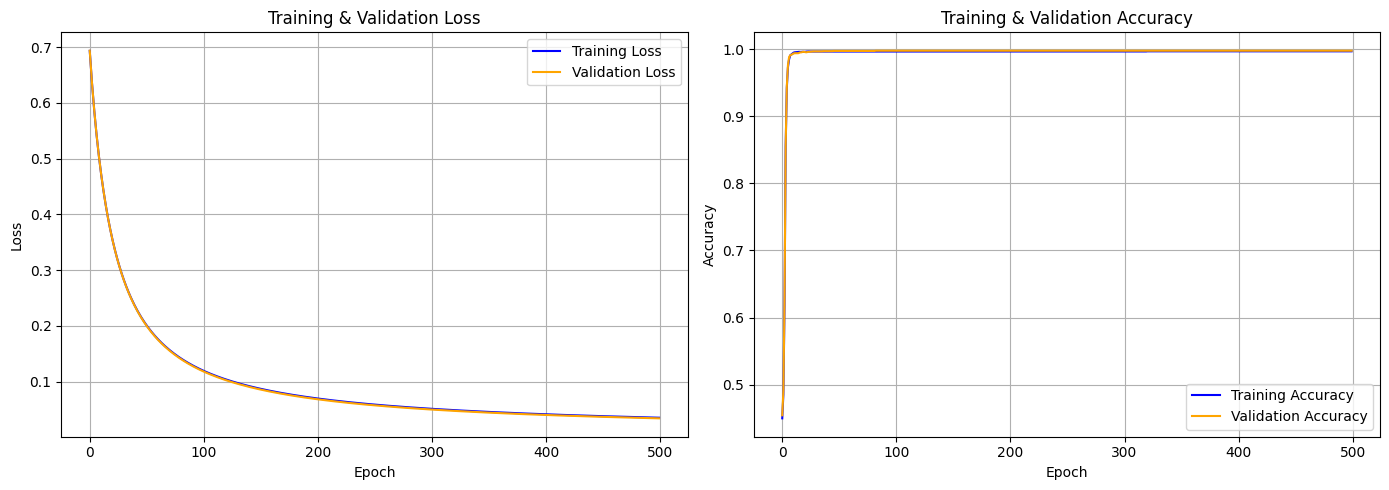

In [8]:
plt.figure(figsize=(14, 5))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='orange')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy', color='blue')
plt.plot(val_accuracies, label='Validation Accuracy', color='orange')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Test Model

Final Test Accuracy (0 vs 1): 0.9970


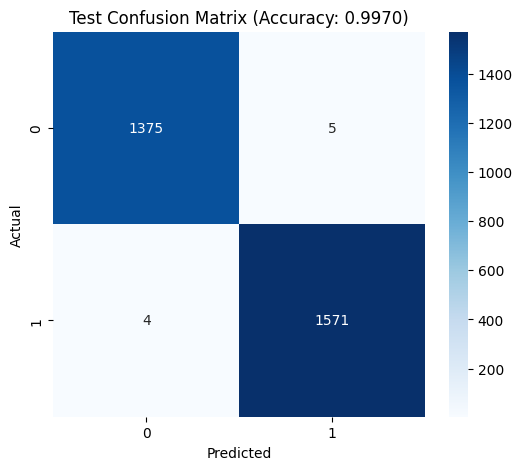

In [11]:
# Final test forward pass
z_test = X_test_bin @ W + b
y_pred_test = sigmoid(z_test)
y_pred_test_label = (y_pred_test >= 0.5).float()

# Compute test accuracy
test_acc_logistic = accuracy_score(y_test_bin.numpy(), y_pred_test_label.numpy())
print(f"Final Test Accuracy (0 vs 1): {test_acc_logistic:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test_bin.numpy(), y_pred_test_label.numpy())
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.title(f'Test Confusion Matrix (Accuracy: {test_acc_logistic:.4f})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Task A3

### Imports

In [12]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

### Implement Softmax

In [13]:
# Set seed for reproducibility
torch.manual_seed(42)

# Dimensions
input_dim = 784   # flattened image
num_classes = 10  # digits 0-9

# Initialize weights and bias
W = torch.randn(input_dim, num_classes, requires_grad=False) * 0.01  # (784, 10)
b = torch.zeros(num_classes, requires_grad=False)                     # (10,)

def softmax(z):
    # Subtract max for numerical stability
    z = z - z.max(dim=1, keepdim=True)[0]
    exp_z = torch.exp(z)
    return exp_z / exp_z.sum(dim=1, keepdim=True)

def cross_entropy_loss(y_true, y_pred):
    """
    y_true: (N,) long tensor of class indices
    y_pred: (N, 10) probability distribution (after softmax)
    """
    # One-hot encode y_true
    y_true_onehot = F.one_hot(y_true, num_classes=10).float()  # (N, 10)
    
    # Clip predictions to avoid log(0)
    y_pred_clipped = torch.clamp(y_pred, 1e-15, 1 - 1e-15)
    
    # Cross-entropy: -sum(y_true * log(y_pred))
    loss = - (y_true_onehot * torch.log(y_pred_clipped)).sum(dim=1).mean()
    return loss

### Train Model

In [14]:
learning_rate = 0.01
num_epochs = 1000 # Trained for 500, then did 1000 more because accuracy was low. Total 1500 epochs
print_every = 50

# Lists to store metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    # -------------------
    # Forward Pass (Training)
    # -------------------
    z = X_train_tensor @ W + b           # Linear output: (N, 10)
    y_pred_train = softmax(z)            # Softmax output: (N, 10)
    y_pred_train_label = torch.argmax(y_pred_train, dim=1)  # Predicted class

    # Compute loss and accuracy
    loss = cross_entropy_loss(y_train_tensor, y_pred_train)
    acc = accuracy_score(y_train_tensor.numpy(), y_pred_train_label.numpy())

    # -------------------
    # Validation Pass
    # -------------------
    z_val = X_val_tensor @ W + b
    y_pred_val = softmax(z_val)
    y_pred_val_label = torch.argmax(y_pred_val, dim=1)

    val_loss = cross_entropy_loss(y_val_tensor, y_pred_val)
    val_acc = accuracy_score(y_val_tensor.numpy(), y_pred_val_label.numpy())

    # Store metrics
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    train_accuracies.append(acc)
    val_accuracies.append(val_acc)

    # -------------------
    # Manual Gradient Descent
    # -------------------
    m = X_train_tensor.shape[0]  # batch size

    # One-hot labels for gradient
    y_true_onehot = F.one_hot(y_train_tensor, num_classes=10).float()  # (N, 10)

    # Gradient of loss w.r.t. logits (z): (y_pred - y_true) / N
    dz = (y_pred_train - y_true_onehot) / m  # (N, 10)

    # Gradients w.r.t. W and b
    dW = X_train_tensor.t() @ dz           # (784, 10)
    db = dz.sum(dim=0)                     # (10,)

    # Update parameters
    W = W - learning_rate * dW
    b = b - learning_rate * db

    # Print progress
    if (epoch+1) % print_every == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {loss:.4f}, Val Loss: {val_loss:.4f}, "
              f"Train Acc: {acc:.4f}, Val Acc: {val_acc:.4f}")

Epoch [50/1000], Train Loss: 1.8557, Val Loss: 1.8572, Train Acc: 0.7302, Val Acc: 0.7332
Epoch [100/1000], Train Loss: 1.5506, Val Loss: 1.5530, Train Acc: 0.7744, Val Acc: 0.7779
Epoch [150/1000], Train Loss: 1.3395, Val Loss: 1.3426, Train Acc: 0.7943, Val Acc: 0.7954
Epoch [200/1000], Train Loss: 1.1896, Val Loss: 1.1929, Train Acc: 0.8078, Val Acc: 0.8081
Epoch [250/1000], Train Loss: 1.0792, Val Loss: 1.0827, Train Acc: 0.8169, Val Acc: 0.8156
Epoch [300/1000], Train Loss: 0.9951, Val Loss: 0.9988, Train Acc: 0.8244, Val Acc: 0.8238
Epoch [350/1000], Train Loss: 0.9291, Val Loss: 0.9329, Train Acc: 0.8300, Val Acc: 0.8301
Epoch [400/1000], Train Loss: 0.8760, Val Loss: 0.8798, Train Acc: 0.8345, Val Acc: 0.8345
Epoch [450/1000], Train Loss: 0.8322, Val Loss: 0.8360, Train Acc: 0.8382, Val Acc: 0.8373
Epoch [500/1000], Train Loss: 0.7955, Val Loss: 0.7994, Train Acc: 0.8421, Val Acc: 0.8401
Epoch [550/1000], Train Loss: 0.7642, Val Loss: 0.7682, Train Acc: 0.8449, Val Acc: 0.8431


### Plot Learning Curves

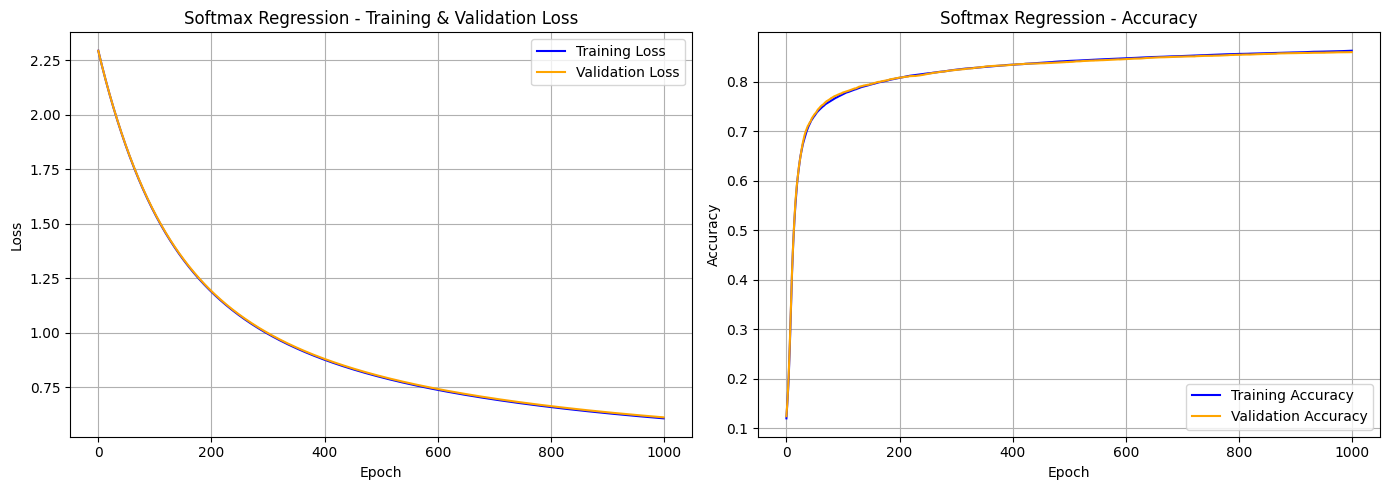

In [15]:
plt.figure(figsize=(14, 5))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='orange')
plt.title('Softmax Regression - Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy', color='blue')
plt.plot(val_accuracies, label='Validation Accuracy', color='orange')
plt.title('Softmax Regression - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Compare with PyTorch Built-In Model

In [ ]:
# Compute loss using PyTorch built-in
z_torch = X_train_tensor @ W + b
loss_torch = F.cross_entropy(z_torch, y_train_tensor)

print(f"Manual Cross-Entropy Loss: {loss:.6f}")
print(f"PyTorch F.cross_entropy:   {loss_torch.item():.6f}")
print(f"Difference: {abs(loss - loss_torch.item()):.8f}")

### Test Model

Final Test Accuracy (Softmax Regression): 0.8606


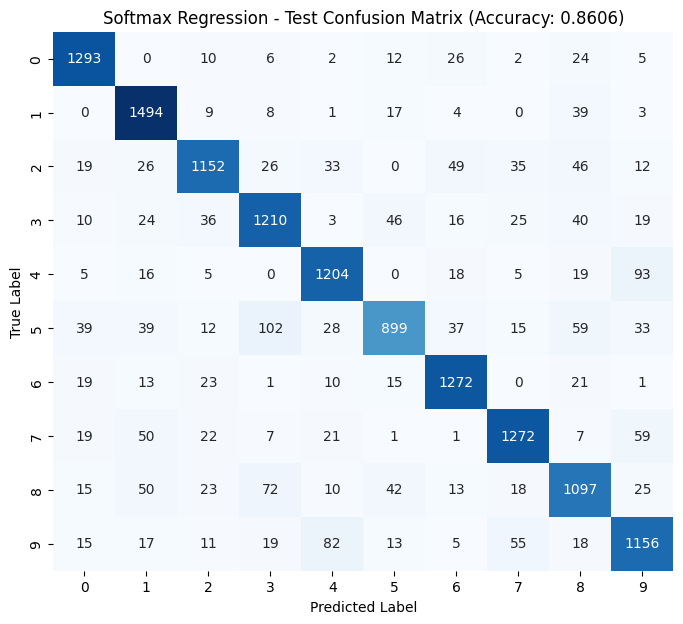

In [17]:
# Final test forward pass
z_test = X_test_tensor @ W + b
y_pred_test = softmax(z_test)
y_pred_test_label = torch.argmax(y_pred_test, dim=1)

# Test accuracy
test_acc_softmax = accuracy_score(y_test_tensor.numpy(), y_pred_test_label.numpy())
print(f"Final Test Accuracy (Softmax Regression): {test_acc_softmax:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test_tensor.numpy(), y_pred_test_label.numpy())
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Softmax Regression - Test Confusion Matrix (Accuracy: {test_acc_softmax:.4f})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Per-Class Accuracy

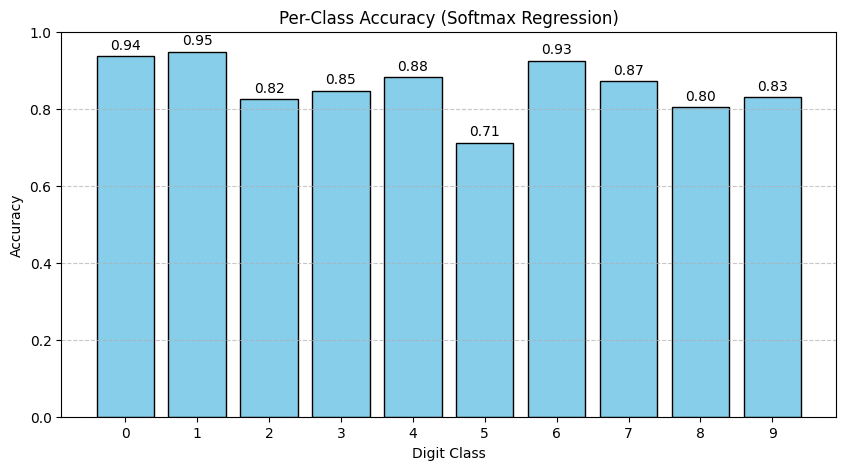

Class 0: 0.9370
Class 1: 0.9486
Class 2: 0.8240
Class 3: 0.8467
Class 4: 0.8821
Class 5: 0.7118
Class 6: 0.9251
Class 7: 0.8718
Class 8: 0.8037
Class 9: 0.8311


In [18]:
# Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)
class_labels = [str(i) for i in range(10)]

plt.figure(figsize=(10, 5))
plt.bar(class_labels, per_class_acc, color='skyblue', edgecolor='black')
plt.title('Per-Class Accuracy (Softmax Regression)')
plt.xlabel('Digit Class')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for i, acc in enumerate(per_class_acc):
    plt.text(i, acc + 0.01, f"{acc:.2f}", ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Print numerical values
for i, acc in enumerate(per_class_acc):
    print(f"Class {i}: {acc:.4f}")

# Part C

## Task C1: Hyperparameter Analysis

### Imports for Part C

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
import time
from collections import defaultdict

### Neural Network Implementation (for comparison)

In [20]:
class FeedForwardNN(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=[128, 64], output_dim=10):
        super(FeedForwardNN, self).__init__()
        self.layers = nn.ModuleList()
        
        # Input layer
        self.layers.append(nn.Linear(input_dim, hidden_dims[0]))
        
        # Hidden layers
        for i in range(1, len(hidden_dims)):
            self.layers.append(nn.Linear(hidden_dims[i-1], hidden_dims[i]))
        
        # Output layer
        self.output = nn.Linear(hidden_dims[-1], output_dim)
        
        # Initialize weights using Xavier initialization
        for layer in self.layers:
            nn.init.xavier_uniform_(layer.weight)
        nn.init.xavier_uniform_(self.output.weight)
    
    def forward(self, x):
        for layer in self.layers:
            x = torch.relu(layer(x))
        x = self.output(x)
        return x

### Train model on neural network

In [21]:
def train_model(model, train_loader, val_loader, learning_rate=0.01, 
                num_epochs=50, device='cpu', verbose=True):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Track statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # Validation
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_loss = running_loss / len(val_loader)
        val_acc = correct / total
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        if verbose and (epoch+1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], "
                  f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, "
                  f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")
    
    return train_losses, val_losses, train_accs, val_accs

### Prepare Data Loaders for Neural Network

In [22]:
# Convert to PyTorch tensors (keep original image shape)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create datasets and loaders
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

### C1.1: Learning Rate Analysis

In [25]:
learning_rates = [0.001, 0.01, 0.1, 1.0]
results_lr = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for lr in learning_rates:
    print(f"\nTraining with learning rate: {lr}")
    model = FeedForwardNN(hidden_dims=[128, 64])
    train_losses, val_losses, train_accs, val_accs = train_model(
        model, train_loader, val_loader, learning_rate=lr, num_epochs=50, verbose=False
    )
    
    results_lr['train_loss'].append(train_losses)
    results_lr['val_loss'].append(val_losses)
    results_lr['train_acc'].append(train_accs)
    results_lr['val_acc'].append(val_accs)


Training with learning rate: 0.001

Training with learning rate: 0.01

Training with learning rate: 0.1

Training with learning rate: 1.0


### Plot Learning Rate Results

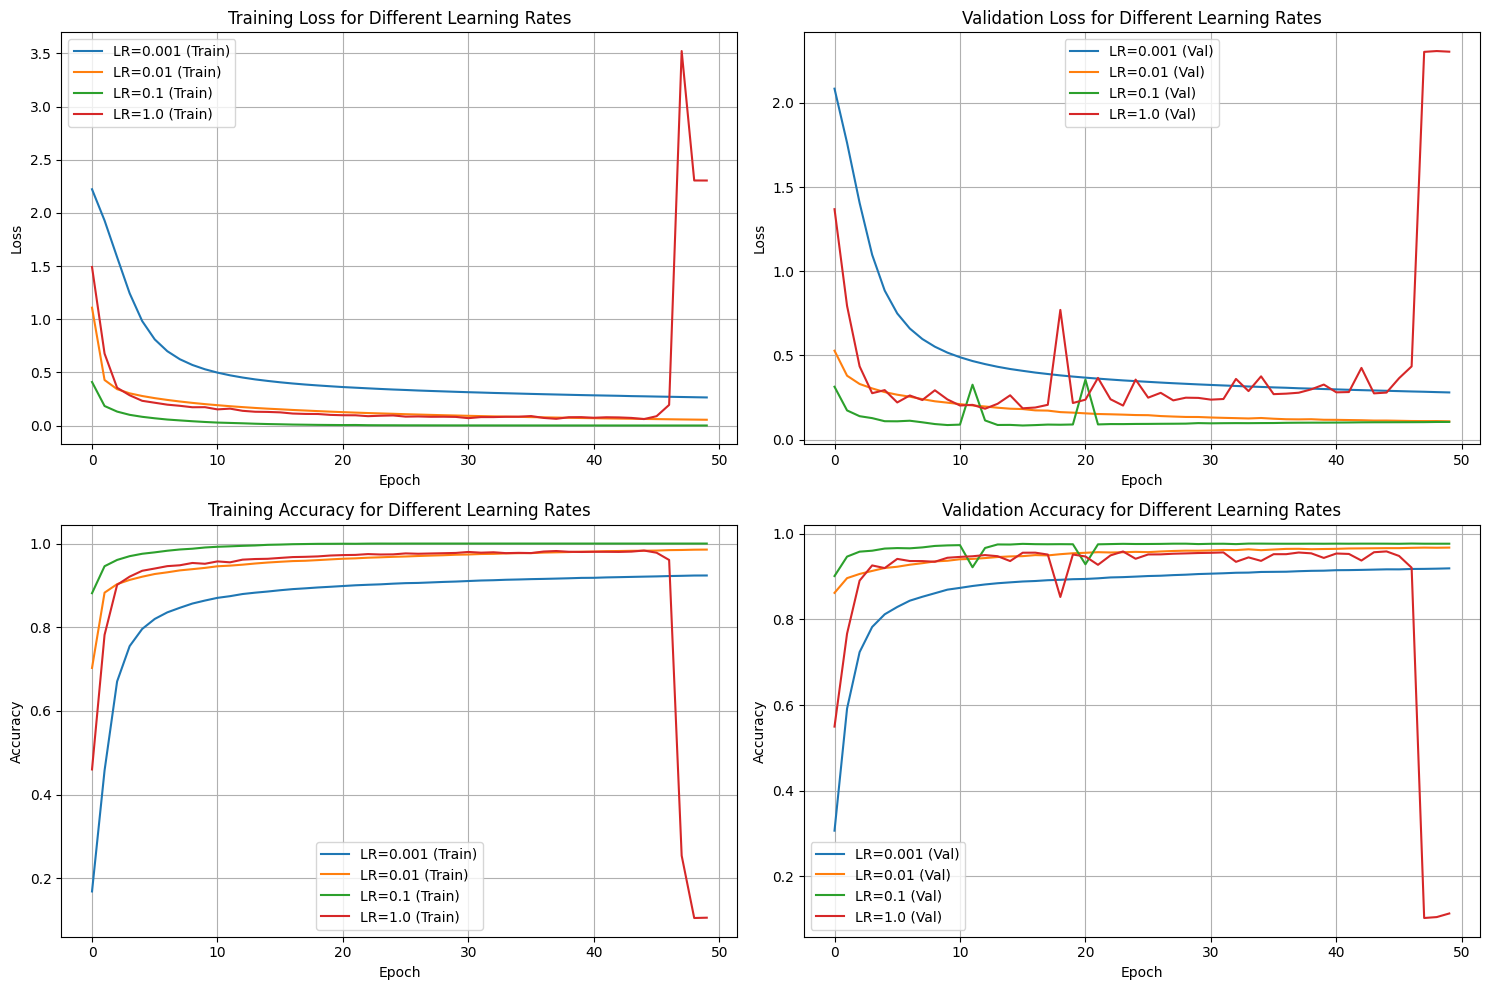

In [26]:

plt.figure(figsize=(15, 10))

# Loss curves
plt.subplot(2, 2, 1)
for i, lr in enumerate(learning_rates):
    plt.plot(results_lr['train_loss'][i], label=f"LR={lr} (Train)")
plt.title('Training Loss for Different Learning Rates')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
for i, lr in enumerate(learning_rates):
    plt.plot(results_lr['val_loss'][i], label=f"LR={lr} (Val)")
plt.title('Validation Loss for Different Learning Rates')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy curves
plt.subplot(2, 2, 3)
for i, lr in enumerate(learning_rates):
    plt.plot(results_lr['train_acc'][i], label=f"LR={lr} (Train)")
plt.title('Training Accuracy for Different Learning Rates')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
for i, lr in enumerate(learning_rates):
    plt.plot(results_lr['val_acc'][i], label=f"LR={lr} (Val)")
plt.title('Validation Accuracy for Different Learning Rates')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

 ### Task C1.2 (Batch Size Analysis)

In [36]:
batch_sizes = [16, 32, 64, 128]
results_bs = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for bs in batch_sizes:
    print(f"\nTraining with batch size: {bs}")
    # Create new data loaders with current batch size
    # Reshape: flatten 28x28 images to 784-dimensional vectors
    X_train_flat = X_train.reshape(X_train.shape[0], -1)  # (42000, 784)
    X_val_flat = X_val.reshape(X_val.shape[0], -1)        # (14000, 784)
    X_test_flat = X_test.reshape(X_test.shape[0], -1)     # (14000, 784)
    
    # Convert to PyTorch tensors
    X_train_tensor = torch.tensor(X_train_flat, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    
    X_val_tensor = torch.tensor(X_val_flat, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)
    
    X_test_tensor = torch.tensor(X_test_flat, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)
    
    # Create TensorDataset for each split
    train_dataset_flat = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset_flat = TensorDataset(X_val_tensor, y_val_tensor)
    test_dataset_flat = TensorDataset(X_test_tensor, y_test_tensor)
    
    train_loader = DataLoader(train_dataset_flat, batch_size=bs, shuffle=True)
    val_loader = DataLoader(val_dataset_flat, batch_size=bs, shuffle=False)
    test_loader = DataLoader(test_dataset_flat, batch_size=bs, shuffle=False)
    
    model = FeedForwardNN(hidden_dims=[128, 64])
    train_losses, val_losses, train_accs, val_accs = train_model(
        model, train_loader, val_loader, learning_rate=0.01, num_epochs=50, verbose=False
    )
    
    results_bs['train_loss'].append(train_losses)
    results_bs['val_loss'].append(val_losses)
    results_bs['train_acc'].append(train_accs)
    results_bs['val_acc'].append(val_accs)



Training with batch size: 16


/tmp/ipykernel_36/3194660772.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_tensor = torch.tensor(X_train_flat, dtype=torch.float32)
/tmp/ipykernel_36/3194660772.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_tensor = torch.tensor(y_train, dtype=torch.long)



Training with batch size: 32

Training with batch size: 64

Training with batch size: 128


### Plot Batch Size Results

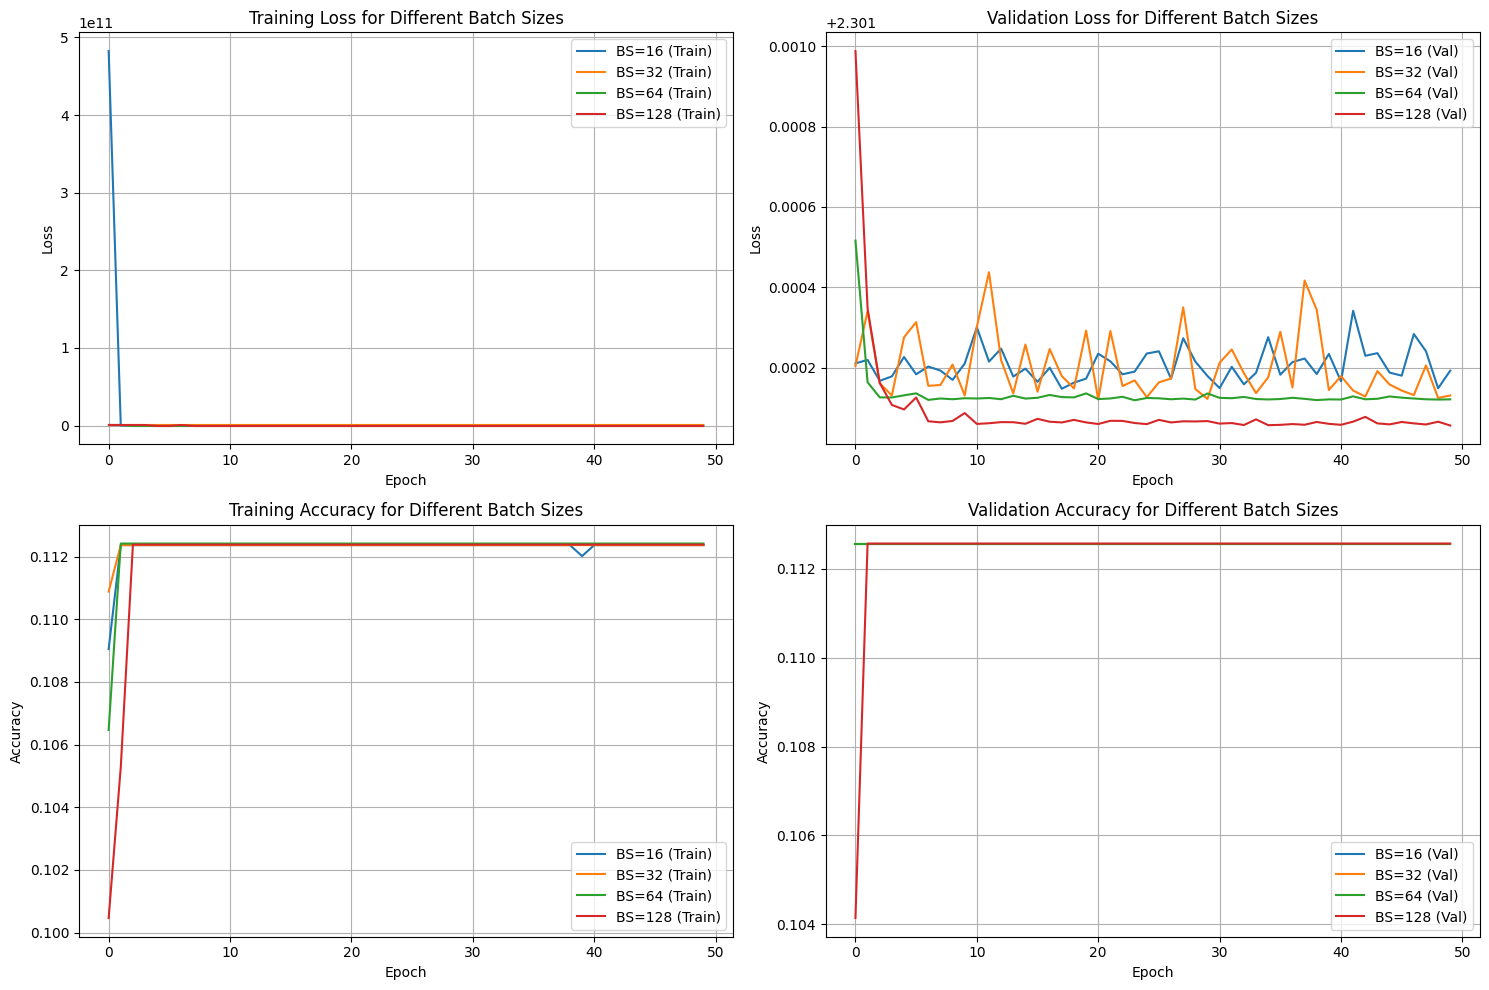

In [37]:

plt.figure(figsize=(15, 10))

# Loss curves
plt.subplot(2, 2, 1)
for i, bs in enumerate(batch_sizes):
    plt.plot(results_bs['train_loss'][i], label=f"BS={bs} (Train)")
plt.title('Training Loss for Different Batch Sizes')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
for i, bs in enumerate(batch_sizes):
    plt.plot(results_bs['val_loss'][i], label=f"BS={bs} (Val)")
plt.title('Validation Loss for Different Batch Sizes')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy curves
plt.subplot(2, 2, 3)
for i, bs in enumerate(batch_sizes):
    plt.plot(results_bs['train_acc'][i], label=f"BS={bs} (Train)")
plt.title('Training Accuracy for Different Batch Sizes')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
for i, bs in enumerate(batch_sizes):
    plt.plot(results_bs['val_acc'][i], label=f"BS={bs} (Val)")
plt.title('Validation Accuracy for Different Batch Sizes')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### C1.3: Architecture Analysis

In [38]:
# Layer configurations
layer_configs = [
    [64],            # 1 hidden layer
    [128, 64],       # 2 hidden layers
    [256, 128, 64],  # 3 hidden layers
    [512, 256, 128, 64]  # 4 hidden layers
]

results_arch = {
    'config': [],
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': [],
    'params': []
}

for config in layer_configs:
    print(f"\nTraining with architecture: {config}")
    model = FeedForwardNN(hidden_dims=config)
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    results_arch['params'].append(total_params)
    results_arch['config'].append(str(config))
    
    train_losses, val_losses, train_accs, val_accs = train_model(
        model, train_loader, val_loader, learning_rate=0.01, num_epochs=50, verbose=False
    )
    
    results_arch['train_loss'].append(train_losses)
    results_arch['val_loss'].append(val_losses)
    results_arch['train_acc'].append(train_accs)
    results_arch['val_acc'].append(val_accs)


Training with architecture: [64]

Training with architecture: [128, 64]

Training with architecture: [256, 128, 64]

Training with architecture: [512, 256, 128, 64]


### Plot Architecture Results

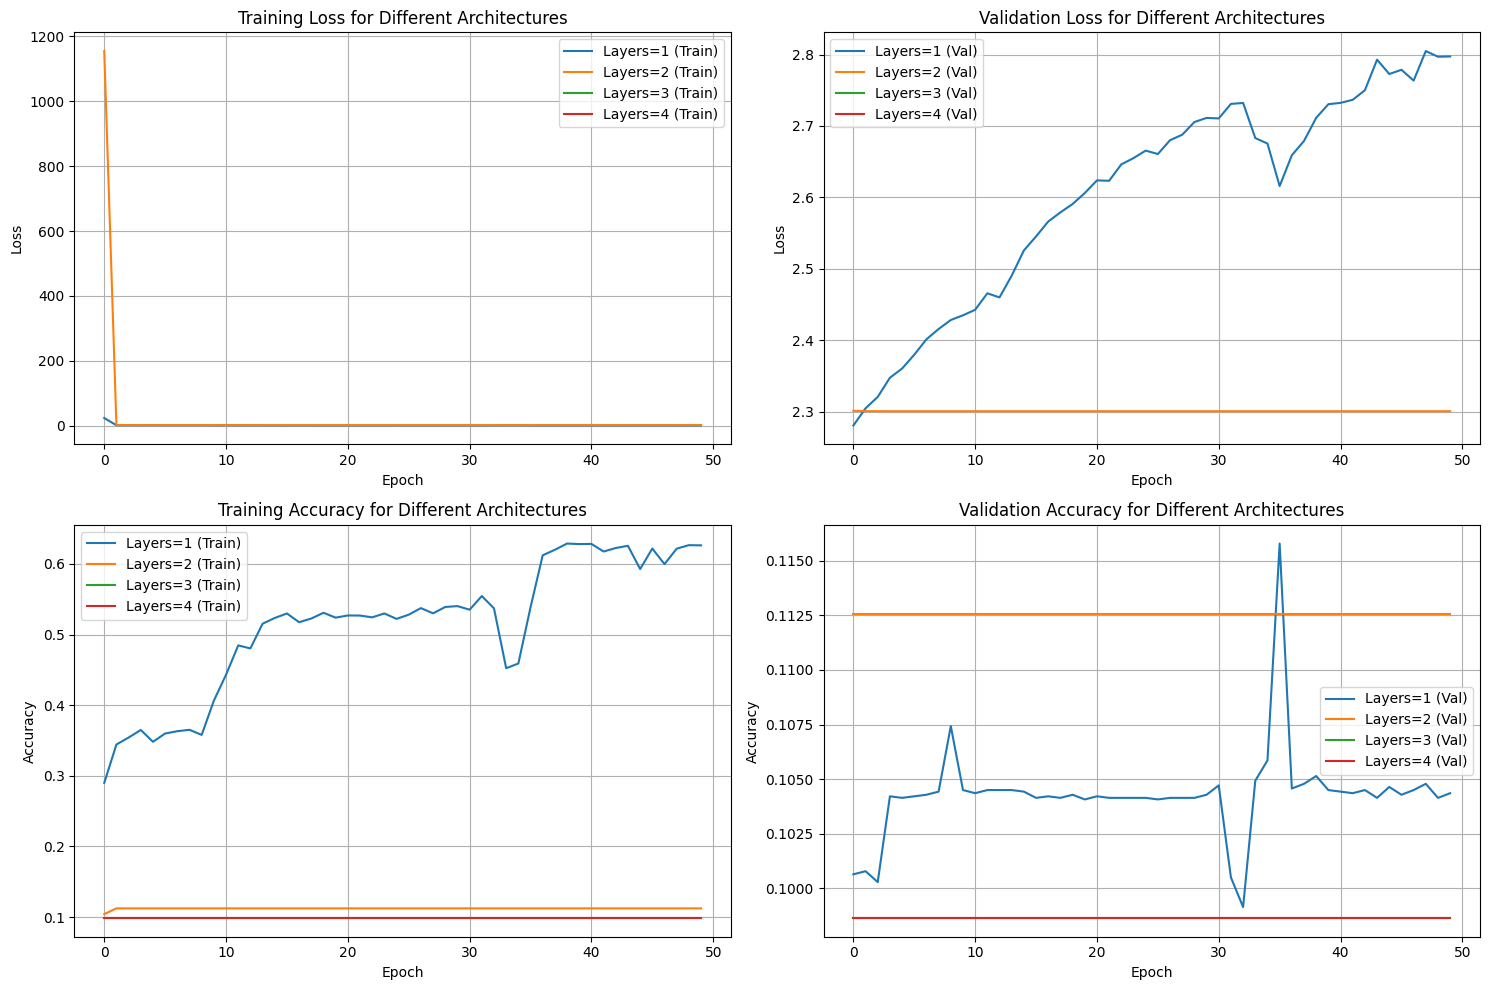


Architecture Comparison:
Config               Params          Final Train Acc Final Val Acc
[64]                 50890           0.6262          0.1044
[128, 64]            109386          0.1124          0.1126
[256, 128, 64]       242762          0.0987          0.0986
[512, 256, 128, 64]  575050          0.0987          0.0986


In [39]:
plt.figure(figsize=(15, 10))

# Loss curves
plt.subplot(2, 2, 1)
for i, config in enumerate(layer_configs):
    plt.plot(results_arch['train_loss'][i], label=f"Layers={len(config)} (Train)")
plt.title('Training Loss for Different Architectures')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
for i, config in enumerate(layer_configs):
    plt.plot(results_arch['val_loss'][i], label=f"Layers={len(config)} (Val)")
plt.title('Validation Loss for Different Architectures')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy curves
plt.subplot(2, 2, 3)
for i, config in enumerate(layer_configs):
    plt.plot(results_arch['train_acc'][i], label=f"Layers={len(config)} (Train)")
plt.title('Training Accuracy for Different Architectures')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
for i, config in enumerate(layer_configs):
    plt.plot(results_arch['val_acc'][i], label=f"Layers={len(config)} (Val)")
plt.title('Validation Accuracy for Different Architectures')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Architecture Comparison Table
print("\nArchitecture Comparison:")
print("Config".ljust(20), "Params".ljust(15), "Final Train Acc", "Final Val Acc")
for i in range(len(layer_configs)):
    config_str = str(layer_configs[i])
    params = results_arch['params'][i]
    train_acc = results_arch['train_acc'][i][-1]
    val_acc = results_arch['val_acc'][i][-1]
    print(f"{config_str.ljust(20)} {str(params).ljust(15)} {train_acc:.4f}          {val_acc:.4f}")

## Task C2: Model Comparison

### Comparative Analysis:

In [40]:
### Evaluate Logistic Regression (0 vs 1) from Part A2
# Calculate accuracy for 0 vs 1 classification
logistic_acc = test_acc_logistic  # From Part A2

### Evaluate Softmax Regression from Part A3
# Calculate accuracy for 10-class classification
softmax_acc = test_acc_softmax  # From Part A3

### Evaluate Best Neural Network
# Select best architecture based on validation accuracy
best_idx = np.argmax([accs[-1] for accs in results_arch['val_acc']])
best_config = layer_configs[best_idx]
print(f"\nBest architecture: {best_config}")

# Train best model with more epochs
best_model = FeedForwardNN(hidden_dims=best_config)
train_losses, val_losses, train_accs, val_accs = train_model(
    best_model, train_loader, val_loader, learning_rate=0.01, num_epochs=100
)

# Evaluate on test set
best_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = best_model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

nn_acc = correct / total
print(f"Test Accuracy (Neural Network): {nn_acc:.4f}")


Best architecture: [128, 64]
Epoch [10/100], Train Loss: 2.3011, Val Loss: 2.3011, Train Acc: 0.1124, Val Acc: 0.1126
Epoch [20/100], Train Loss: 2.3011, Val Loss: 2.3011, Train Acc: 0.1124, Val Acc: 0.1126
Epoch [30/100], Train Loss: 2.3011, Val Loss: 2.3011, Train Acc: 0.1124, Val Acc: 0.1126
Epoch [40/100], Train Loss: 2.3011, Val Loss: 2.3011, Train Acc: 0.1124, Val Acc: 0.1126
Epoch [50/100], Train Loss: 2.3011, Val Loss: 2.3011, Train Acc: 0.1124, Val Acc: 0.1126
Epoch [60/100], Train Loss: 2.3011, Val Loss: 2.3011, Train Acc: 0.1124, Val Acc: 0.1126
Epoch [70/100], Train Loss: 2.3011, Val Loss: 2.3011, Train Acc: 0.1124, Val Acc: 0.1126
Epoch [80/100], Train Loss: 2.3011, Val Loss: 2.3011, Train Acc: 0.1124, Val Acc: 0.1126
Epoch [90/100], Train Loss: 2.3011, Val Loss: 2.3011, Train Acc: 0.1124, Val Acc: 0.1126
Epoch [100/100], Train Loss: 2.3011, Val Loss: 2.3011, Train Acc: 0.1124, Val Acc: 0.1126
Test Accuracy (Neural Network): 0.1125


### Model Comparison Table

In [41]:
print("\nModel Comparison:")
print("Model".ljust(20), "Accuracy".ljust(15), "Parameters")
print(f"{'Logistic (0 vs 1)'.ljust(20)} {logistic_acc:.4f}          {'-'}")
print(f"{'Softmax (10-class)'.ljust(20)} {softmax_acc:.4f}          {'-'}")
print(f"{'Neural Network'.ljust(20)} {nn_acc:.4f}          {results_arch['params'][best_idx]}")


Model Comparison:
Model                Accuracy        Parameters
Logistic (0 vs 1)    0.9970          -
Softmax (10-class)   0.8606          -
Neural Network       0.1125          109386


### Best Model Evaluation

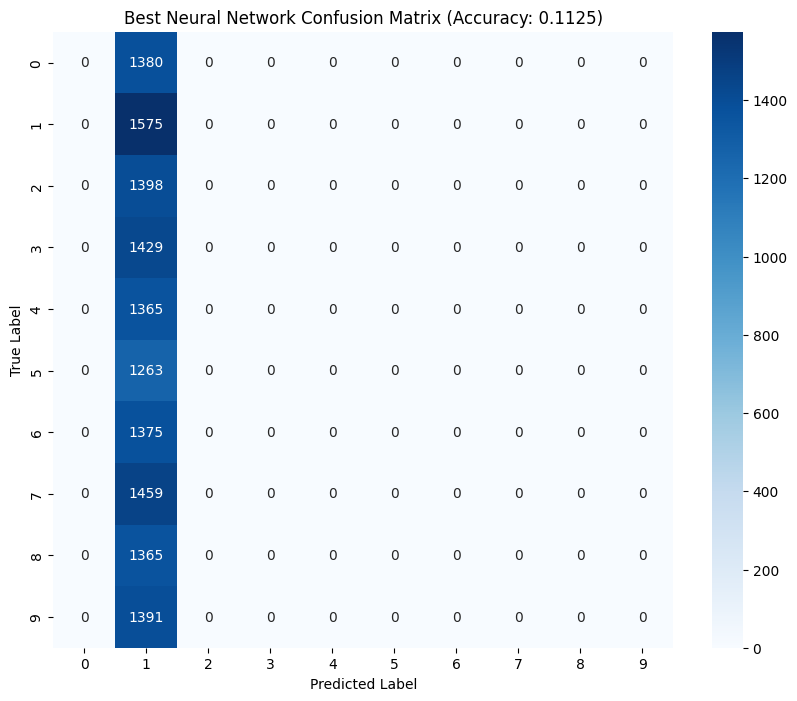

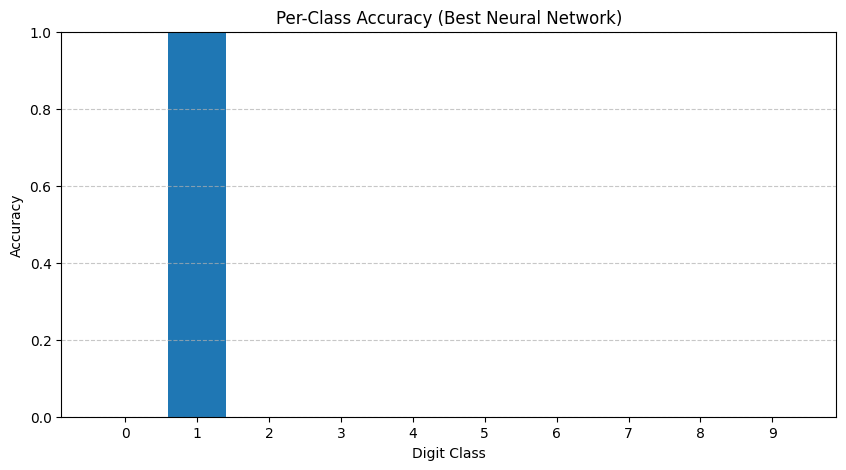

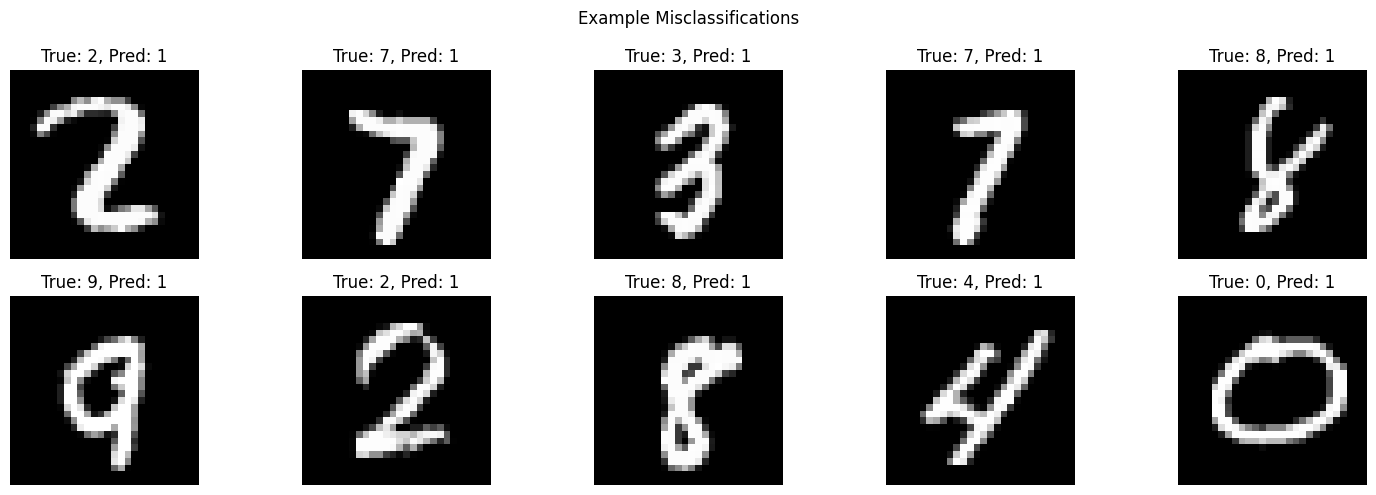

In [42]:
# Confusion Matrix
best_model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = best_model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.title(f'Best Neural Network Confusion Matrix (Accuracy: {nn_acc:.4f})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Per-Class Accuracy
class_acc = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(10, 5))
plt.bar(range(10), class_acc)
plt.title('Per-Class Accuracy (Best Neural Network)')
plt.xlabel('Digit Class')
plt.ylabel('Accuracy')
plt.xticks(range(10))
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Analysis of Misclassifications
misclassified_indices = np.where(np.array(all_labels) != np.array(all_preds))[0]
misclassified_samples = X_test[misclassified_indices][:10]
true_labels = np.array(all_labels)[misclassified_indices][:10]
pred_labels = np.array(all_preds)[misclassified_indices][:10]

plt.figure(figsize=(15, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(misclassified_samples[i].reshape(28, 28), cmap='gray')
    plt.title(f"True: {true_labels[i]}, Pred: {pred_labels[i]}")
    plt.axis('off')
plt.suptitle('Example Misclassifications')
plt.tight_layout()
plt.show()